In [4]:
# load data
import pandas as pd

df = pd.read_csv('sentiment_data.csv')

print(df.shape)
print(df.head(3))

(40, 2)
                                   sentence  label
0                        I love this movie!      1
1       This film was absolutely fantastic.      1
2  One of the best movies I have ever seen.      1


In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer
import math

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

sentences = df['sentence'].tolist()
labels = torch.tensor(df['label'].tolist())

encoded = tokenizer(
    sentences,
    padding=True,        # pad all sentences to the same length
    truncation=True,     # cut if longer than max_length
    max_length=32,       # short enough to run fast on CPU
    return_tensors="pt"  # return PyTorch tensors directly
)

input_ids      = encoded['input_ids']       # (num_sentences, seq_len)
attention_mask = encoded['attention_mask']  # 1 = real token, 0 = padding

print("input_ids shape:", input_ids.shape)
print("first sentence tokens:", input_ids[0])
print("first sentence mask:  ", attention_mask[0])

In [ ]:
from torch.utils.data import Dataset, DataLoader, random_split

# split 100 examples into 80 train / 20 test
train_indices, test_indices = random_split(
    range(len(labels)),
    [80, 20],
    generator=torch.Generator().manual_seed(42)
)
train_indices = list(train_indices)
test_indices  = list(test_indices)

print(f"Train: {len(train_indices)} examples")
print(f"Test:  {len(test_indices)} examples")

In [35]:
class SentimentDataset(Dataset):                                                                   
    def __init__(self, indices):
        self.input_ids      = input_ids[indices]
        self.attention_mask = attention_mask[indices]                                              
        self.labels         = labels[indices]
                                                                                                    
    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):                                                                    
        return {
            'input_ids':      self.input_ids[idx],                                                 
            'attention_mask': self.attention_mask[idx],
            'label':          self.labels[idx],
        }

train_dataset = SentimentDataset(train_indices)
test_dataset  = SentimentDataset(test_indices)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)     # each time 8 batches are randomly sampled from the training set                           
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False)

batch = next(iter(train_loader)) # fetch the first batch from the training set
print("input_ids shape:", batch['input_ids'].shape)                                                
print("labels:         ", batch['label'])

input_ids shape: torch.Size([8, 15])
labels:          tensor([1, 1, 0, 0, 1, 1, 0, 1])


In [42]:
# the model
class Config:   
    def __init__(self):                                                                            
        self.vocab_size    = 30522
        self.dim           = 128        # was 768 — much smaller, faster on CPU                    
        self.n_heads       = 4          # was 12                                                   
        self.head_dim      = self.dim // self.n_heads  # 32
        self.n_layers      = 2          # was 6                                                    
        self.ffn_hidden    = 256        # was 3072 (4 * dim)
        self.max_position  = 512                                                                   
        self.eps           = 1e-12
        self.n_classes     = 2                                                                      

In [43]:
# Embedding layer : token embedding + positional embedding
class Embeddings(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.word_embedding = nn.Embedding(config.vocab_size, config.dim)
        self.position_embedding = nn.Embedding(config.max_position, config.dim)
        self.layer_norm = nn.LayerNorm(config.dim, eps=config.eps)
    
    def forward(self, input_ids):
        word_embeds = self.word_embedding(input_ids)
        seq_len = input_ids.shape[1]
        position_ids = torch.arange(seq_len).unsqueeze(0) # (1, seq_len)
        position_embeds = self.position_embedding(position_ids)

        embeddings = word_embeds + position_embeds
        embeddings = self.layer_norm(embeddings)
        return embeddings

In [44]:
# Attention Block
class AttentionBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_heads = config.n_heads
        self.head_dim = config.head_dim
        self.dim = config.dim

        # multi heads attention projections
        # process 12 heads together for efficiency, later split into 12 heads
        self.q_lin = nn.Linear(config.dim, config.dim) # process all heads together
        self.k_lin = nn.Linear(config.dim, config.dim)
        self.v_lin = nn.Linear(config.dim, config.dim)
        self.out_lin = nn.Linear(config.dim, config.dim)

        # layer norm
        self.attn_layer_norm = nn.LayerNorm(config.dim, eps=config.eps)
        self.ffn_layer_norm = nn.LayerNorm(config.dim, eps=config.eps)

        # feed forward network
        self.lin1 = nn.Linear(config.dim, config.ffn_hidden)
        self.lin2 = nn.Linear(config.ffn_hidden, config.dim)
    
    def forward(self, x):
        batch, seq_len, dim = x.shape

        # --- Multi-head self-attention ---

        # 1. project input to Q, K, V
        Q = self.q_lin(x) # (batch, seq_len, dim)
        K = self.k_lin(x)
        V = self.v_lin(x)

        # 2. split into 12 heads
        # from (1, 10, 768) to (1, 10, 12, 64) --> (1, 12, 10, 64)
        Q = Q.reshape(batch, seq_len, self.n_heads, self.head_dim).transpose(1, 2) # (batch, n_heads, seq_len, head_dim)
        K = K.reshape(batch, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        V = V.reshape(batch, seq_len, self.n_heads, self.head_dim).transpose(1, 2)

        # 3. attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        weights = torch.softmax(scores, dim=-1) # along columns

        # 4. apply weights to V to get context
        context = torch.matmul(weights, V) # (batch, n_heads, seq_len, head_dim)
        
        # 5. merge heads back
        # concatenate context from 12 heads: (1, 12, 10, 64) --> (1, 10, 12, 64) --> (1, 10, 768)
        context = context.transpose(1, 2).reshape(batch, seq_len, dim)

        # 6. final linear layer + residul + layer norm
        attn_output = self.out_lin(context)
        x = self.attn_layer_norm(x + attn_output)


        # --- Feed Forward Network ---
        ffn_output = self.lin1(x)
        ffn_output = torch.nn.functional.gelu(ffn_output)
        ffn_output = self.lin2(ffn_output)
        x = self.ffn_layer_norm(x + ffn_output)

        return x, weights


In [45]:
# Encoder
# stack 6 attention blocks in sequence
class Encoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.layers = nn.ModuleList([AttentionBlock(config) for _ in range(config.n_layers)])
    
    def forward(self, x):
        all_weights = []
        for layer in self.layers:
            x, weights = layer(x)
            all_weights.append(weights)
        return x, all_weights

In [46]:
# FULL MODEL
class Transformer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.embeddings = Embeddings(config)
        self.encoder = Encoder(config)
        self.pre_classifier = nn.Linear(config.dim, config.dim)
        self.classifier = nn.Linear(config.dim, config.n_classes)
    
    def forward(self, input_ids):
        # stage 1: token ids --> embeddings
        x = self.embeddings(input_ids) # (batch, seq_len, dim)

        # stage 2: run through all 6 attention blocks through the encoder
        x, all_weights = self.encoder(x) # (batch, seq_len, dim)

        # stage 3 : pooling - grab only the [CLS] token representation (first token)
        x = x[:, 0, :] # (batch, dim)

        # stage 4 : classify
        x = self.pre_classifier(x)
        x = torch.nn.functional.gelu(x)
        logits = self.classifier(x) # (batch, n_classes)

        return logits, all_weights

In [64]:
config = Config()
model = Transformer(config)
with torch.no_grad():
    logits, _ = model(batch['input_ids'])
print(logits.shape) # (8, 2) - batch size, n_classes
print(logits)

torch.Size([8, 2])
tensor([[ 0.0769, -0.2276],
        [ 0.0968, -0.2307],
        [ 0.1296, -0.2189],
        [ 0.1003, -0.2230],
        [ 0.1058, -0.2527],
        [ 0.0870, -0.2168],
        [ 0.0978, -0.2280],
        [ 0.1012, -0.2406]])


In [81]:
model     = Transformer(config)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs   = 100  # set high — early stopping will quit before this
patience = 5    # stop if test loss doesn't improve for 5 epochs in a row

train_loss_history = []
test_loss_history  = []

best_test_loss = float('inf')
best_weights   = None
no_improve     = 0

for epoch in range(epochs):
    # --- training ---
    model.train()
    total_train_loss = 0
    for batch in train_loader:
        logits, _  = model(batch['input_ids'])
        loss       = criterion(logits, batch['label'])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    # --- test loss ---
    model.eval()
    total_test_loss = 0
    with torch.no_grad():
        for batch in test_loader:
            logits, _ = model(batch['input_ids'])
            loss      = criterion(logits, batch['label'])
            total_test_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_test_loss  = total_test_loss  / len(test_loader)

    train_loss_history.append(avg_train_loss)
    test_loss_history.append(avg_test_loss)

    print(f"Epoch {epoch+1:3d} | train: {avg_train_loss:.4f}  test: {avg_test_loss:.4f}")

    # --- early stopping ---
    if avg_test_loss < best_test_loss:
        best_test_loss = avg_test_loss
        best_weights   = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve     = 0
    else:
        no_improve += 1
        if no_improve == patience:
            print(f"\nStopped early at epoch {epoch+1}. Best test loss: {best_test_loss:.4f}")
            break

model.load_state_dict(best_weights)

Epoch   1 | train: 0.7432  test: 0.6902
Epoch   2 | train: 0.6963  test: 0.6884
Epoch   3 | train: 0.6768  test: 0.7177
Epoch   4 | train: 0.6425  test: 0.8419
Epoch   5 | train: 0.4014  test: 1.1952
Epoch   6 | train: 0.0997  test: 1.8681
Epoch   7 | train: 0.0106  test: 2.6668

Stopped early at epoch 7. Best test loss: 0.6884


<All keys matched successfully>

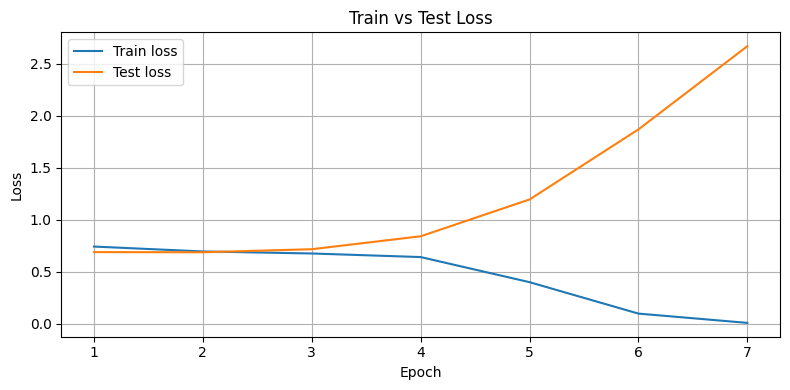

In [84]:
import matplotlib.pyplot as plt

actual_epochs = len(train_loss_history)  # may be less than 100 due to early stopping

plt.figure(figsize=(8, 4))
plt.plot(range(1, actual_epochs + 1), train_loss_history, label='Train loss')
plt.plot(range(1, actual_epochs + 1), test_loss_history,  label='Test loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Test Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [83]:
# evaluation
model.eval()

correct = 0                                                                                        
total   = 0
                                                                                                    
with torch.no_grad():
    for batch in test_loader:
        logits, _ = model(batch['input_ids'])
                                                                                                    
        # convert logits (8, 2) → predicted class (8,) by picking the higher score                 
        predictions = torch.argmax(logits, dim=-1)                                                 
                                                                                                    
        correct += (predictions == batch['label']).sum().item()
        total   += len(batch['label'])                                                             
                
accuracy = correct / total
print(f"Test accuracy: {correct}/{total} = {accuracy*100:.1f}%")


Test accuracy: 11/20 = 55.0%


In [51]:
test_sentences = [df['sentence'][i] for i in test_indices]                                         
all_preds = []                                                                                     
                
with torch.no_grad():                                                                              
    for batch in test_loader:
        logits, _ = model(batch['input_ids'])                                                      
        preds = torch.argmax(logits, dim=-1)
        all_preds.extend(preds.tolist())                                                           
                                                                                                    
label_names = {0: "negative", 1: "positive"}

for sentence, pred, truth in zip(test_sentences, all_preds, [labels[i].item() for i in
  test_indices]):                                                                                    
    status = "correct" if pred == truth else "WRONG"
    print(f"[{status}] pred={label_names[pred]}  truth={label_names[truth]}")                      
    print(f"  '{sentence}'") 

[correct] pred=negative  truth=negative
  'The dialogue was cringeworthy and embarrassing.'
[WRONG] pred=positive  truth=negative
  'I hated this movie.'
[WRONG] pred=positive  truth=negative
  'Dull, slow, and painfully boring.'
[correct] pred=negative  truth=negative
  'The worst movie of the decade.'
[WRONG] pred=positive  truth=negative
  'I fell asleep halfway through.'
[WRONG] pred=positive  truth=negative
  'Avoid this film at all costs.'
[correct] pred=positive  truth=positive
  'This film was absolutely fantastic.'
[correct] pred=positive  truth=positive
  'I really enjoyed every minute of it.'


In [ ]:
it is not possible to train a sentiment classifier transformer with only 100 examples.

Bert uses 110M parameters and is trained on 3.3B words. and this is only for understanding language, not even for sentiment classification.

so i am goona give up on training a sentiment classifier transformer.
